* 데이터셋 준비
* export
* uv run nnUNetv2_plan_and_preprocess -d 1 --verify_dataset_integrity
* uv run nnUNetv2_train 1 2d 0 --npz

---

### 데이터 분할

* 예시 사용을 위한 데이터
    * /segmentation/unet/data/isbi-2012

In [30]:
import os

In [31]:
DATA_DIR = "/home/jovyan/aicon-gamma-datavol-1/hjgoh/ai-lab/segmentation/unet/data/isbi-2012"

In [32]:
# stack load + 분할

# 30장 512x512 unit8 multiframe tifs
# 분할비 train : val : test = 21 : 3 : 6 / 순서대로 분할 
# 이진 마스크 레이블

def load_tif_stack(path):
    # path check
    img = Image.open(path)
    frames = [np.array (img.seek(i) or img) for i in range(img.n_frames)]
    return np.stack(frames, axis=0) # [N, H, W ]

volumes = load_tif_stack(os.path.join(DATA_DIR, "train-volume.tif")) #[30, 512, 512]
labels = load_tif_stack(os.path.join(DATA_DIR, "train-label.tif")) #[30, 512, 512]

N = volumes.shape[0]
train_end = int(N * 0.7)  # 21
val_end = int(N * 0.8)   # 24

train_idx = list(range(0, train_end))       # 0~20
val_idx = list(range(train_end, val_end))   # 21~23
test_idx = list(range(val_end, N))          # 24~29

print(f"train_idx: {train_idx}")
print(f"val_idx: {val_idx}")
print(f"test_idx: {test_idx}")

train_idx: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
val_idx: [21, 22, 23]
test_idx: [24, 25, 26, 27, 28, 29]


In [33]:
NNUNET_RAW = "/home/jovyan/aicon-gamma-datavol-1/hjgoh/ai-lab/segmentation/nnunet/nnUNet_raw"
dataset_dir = os.path.join(NNUNET_RAW, "Dataset001_ISBI2012")

In [34]:
DATA_DIR = "/home/jovyan/aicon-gamma-datavol-1/hjgoh/ai-lab/segmentation/unet/data/isbi-2012"

def load_tif_stack(path):
    img = Image.open(path)
    frames = [np.array(img.seek(i) or img) for i in range(img.n_frames)]
    return np.stack(frames, axis=0)

volumes = load_tif_stack(os.path.join(DATA_DIR, "train-volume.tif"))
labels = load_tif_stack(os.path.join(DATA_DIR, "train-label.tif"))

N = volumes.shape[0]
train_end = int(N * 0.7)
val_end = int(N * 0.8)
train_idx = list(range(0, train_end))
val_idx = list(range(train_end, val_end))
test_idx = list(range(val_end, N))

In [35]:
NNUNET_RAW = "/home/jovyan/aicon-gamma-datavol-1/hjgoh/ai-lab/segmentation/nnunet/nnUNet_raw"
dataset_dir = os.path.join(NNUNET_RAW, "Dataset001_ISBI2012")
images_tr = os.path.join(dataset_dir, "imagesTr")
labels_tr = os.path.join(dataset_dir, "labelsTr")
images_ts = os.path.join(dataset_dir, "imagesTs")
os.makedirs(images_tr, exist_ok=True)
os.makedirs(labels_tr, exist_ok=True)
os.makedirs(images_ts, exist_ok=True)

trainval_idx = train_idx + val_idx

for i in trainval_idx:
    case_id = f"isbi_{i:03d}"
    Image.fromarray(volumes[i]).save(os.path.join(images_tr, f"{case_id}_0000.png"))
    mask = (labels[i] == 0).astype(np.uint8)   # membrane(원본 0)->1, 배경(원본 255)->0
    Image.fromarray(mask).save(os.path.join(labels_tr, f"{case_id}.png"))

for i in test_idx:
    case_id = f"isbi_{i:03d}"
    Image.fromarray(volumes[i]).save(os.path.join(images_ts, f"{case_id}_0000.png"))

test_gt_dir = os.path.join(dataset_dir, "labelsTs_gt_for_our_eval")
os.makedirs(test_gt_dir, exist_ok=True)
for i in test_idx:
    mask = (labels[i] == 0).astype(np.uint8)
    Image.fromarray(mask).save(os.path.join(test_gt_dir, f"isbi_{i:03d}.png"))

dataset_json = {
    "channel_names": {"0": "EM"},
    "labels": {"background": 0, "membrane": 1},
    "numTraining": len(trainval_idx),
    "file_ending": ".png"
}
with open(os.path.join(dataset_dir, "dataset.json"), "w") as f:
    json.dump(dataset_json, f, indent=4)

print(f"imagesTr/labelsTr: {len(trainval_idx)}장, imagesTs: {len(test_idx)}장 저장 완료 (라벨 극성 수정됨)")


NameError: name 'json' is not defined

In [ ]:
p = os.path.join(labels_tr, f"isbi_{trainval_idx[0]:03d}.png")
arr = np.array(Image.open(p))
vals, counts = np.unique(arr, return_counts=True)
print(vals, counts, counts/counts.sum())
# label 1(membrane)의 비율이 소수(20%대)로 나와야 정상

[0 1] [204652  57492] [0.78068542 0.21931458]


### Evaluation

In [ ]:
import os
import matplotlib.pyplot as plt

import numpy as np
from PIL import Image
import pandas as pd

import torch
from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor

In [ ]:
os.environ['nnUNet_raw'] = "/home/jovyan/aicon-gamma-datavol-1/hjgoh/ai-lab/segmentation/nnunet/nnUNet_raw"
os.environ['nnUNet_preprocessed'] = "/home/jovyan/aicon-gamma-datavol-1/hjgoh/ai-lab/segmentation/nnunet/nnUNet_preprocessed"
os.environ['nnUNet_results'] = "/home/jovyan/aicon-gamma-datavol-1/hjgoh/ai-lab/segmentation/nnunet/nnUNet_results"

DATASET_DIR = os.path.join(os.environ['nnUNet_raw'], "Dataset001_ISBI2012")
RESULTS_DIR = os.path.join(os.environ['nnUNet_results'], "Dataset001_ISBI2012", "nnUNetTrainer__nnUNetPlans__2d")
IMAGE_TS = os.path.join(DATASET_DIR, "imagesTs")
LABELS_TS = os.path.join(DATASET_DIR, "labelsTs_gt_for_our_eval")
PRED_TS = os.path.join(RESULTS_DIR, "predTs")
os.makedirs(PRED_TS, exist_ok=True)

In [ ]:
device = torch.device('cuda', 6) if torch.cuda.is_available() else torch.device('cpu')

In [ ]:
predictor = nnUNetPredictor(
    tile_step_size=0.5,         # 패치 겹침
    use_gaussian=True,          # 가우시안 가중 블렌딩
    use_mirroring=True,         # 미러링 사용
    perform_everything_on_device=True,
    device=device,
    verbose=False,
    verbose_preprocessing=False,
    allow_tqdm=True,
)

In [ ]:
predictor.initialize_from_trained_model_folder(
    RESULTS_DIR,
    use_folds=(0, 1, 2, 3, 4),
    checkpoint_name="checkpoint_best.pth",
)

In [ ]:
predictor.predict_from_files(
    IMAGE_TS,
    PRED_TS,
    save_probabilities=False, # 이거 왜 false로? 
    overwrite=True,
    num_processes_preprocessing=2,
    num_processes_segmentation_export=2,
)
print("추론 완료:", PRED_TS)

There are 6 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 6 cases that I would like to predict

Predicting isbi_024:
perform_everything_on_device: True


100%|██████████| 1/1 [00:00<00:00, 39.16it/s]


sending off prediction to background worker for resampling and export
done with isbi_024

Predicting isbi_025:
perform_everything_on_device: True


100%|██████████| 1/1 [00:00<00:00, 40.20it/s]


sending off prediction to background worker for resampling and export
done with isbi_025

Predicting isbi_026:
perform_everything_on_device: True


...

100%|██████████| 1/1 [00:00<00:00, 39.54it/s]


sending off prediction to background worker for resampling and export
done with isbi_028

Predicting isbi_029:
perform_everything_on_device: True


100%|██████████| 1/1 [00:00<00:00, 40.60it/s]


sending off prediction to background worker for resampling and export
done with isbi_029
GPU prediction completed. Waiting for remaining segmentation exports to finish...


Segmentation export complete.
추론 완료: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ai-lab/segmentation/nnunet/nnUNet_results/Dataset001_ISBI2012/nnUNetTrainer__nnUNetPlans__2d/predTs


In [ ]:
# 예측 결과 정리
def dice_score(pred, gt, cls=1):
    p = (pred == cls)
    g = (gt == cls)
    inter = (p & g).sum()
    denom = p.sum() + g.sum()
    return 2 * inter / denom if denom > 0 else 1.0

rows = []
for fname in sorted(os.listdir(LABELS_TS)):
    gt = np.array(Image.open(os.path.join(LABELS_TS, fname)))
    pred = np.array(Image.open(os.path.join(PRED_TS, fname)))
    rows.append({'case': fname, 'dice_membrane': dice_score(pred, gt)})

df_test_dice = pd.DataFrame(rows)
display(df_test_dice)
print("Test 평균 Dice:", df_test_dice['dice_membrane'].mean())

,case,dice_membrane
0,isbi_024.png,0.819395
1,isbi_025.png,0.838437
2,isbi_026.png,0.846362
3,isbi_027.png,0.828301
4,isbi_028.png,0.850650
5,isbi_029.png,0.771565


Test 평균 Dice: 0.8257849497302826


In [ ]:
summary_path = os.path.join(RESULTS_DIR, "test_summary.json")
!nnUNetv2_evaluate_simple {LABELS_TS} {PRED_TS} -l 1 -o {summary_path}

In [29]:
from nnunetv2.evaluation.evaluate_predictions import load_summary_json

result = load_summary_json(summary_path)
print(result['mean'][1]['Dice'])
print(result['foreground_mean']['Dice'])
print(result['foreground_mean']['IoU'])

0.8257849497302826
0.8257849497302826
0.7041058491613844


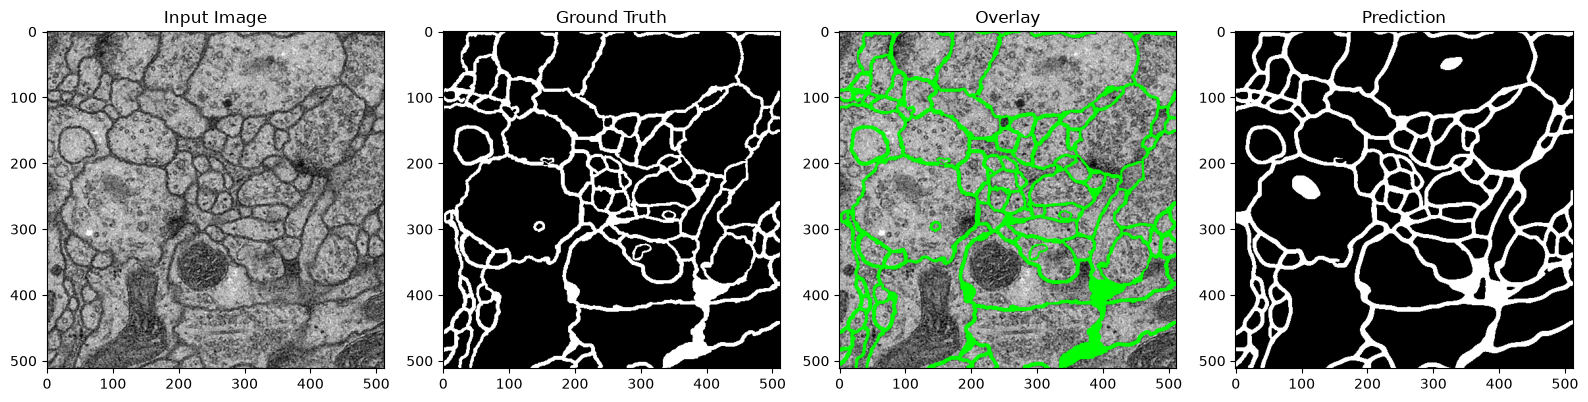

In [28]:
case = "isbi_024_0000.png"
img = np.array(Image.open(os.path.join(IMAGE_TS, case)))
case = "isbi_024.png"
gt = np.array(Image.open(os.path.join(LABELS_TS, case))) 
pred = np.array(Image.open(os.path.join(PRED_TS, case)))


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Input Image')
axes[1].imshow(gt, cmap='gray'); axes[1].set_title('Ground Truth')

overlay = np.stack([img]*3, axis=-1).astype(np.uint8)   # RGB로 변환
overlay[gt == 1] = [0, 255, 0]                          # gt membrane을 초록색으로
axes[2].imshow(overlay); axes[2].set_title('Overlay')

axes[3].imshow(pred, cmap='gray'); axes[3].set_title('Prediction')

plt.tight_layout()
plt.show()